In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import  adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv("D://Machine Learning//sampledata//Projects//Stock_data.csv")
df

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,13.583,13.693,13.430,13.693,156240,0
1,2005-02-28,13.697,13.827,13.540,13.827,370509,0
2,2005-03-01,13.780,13.913,13.720,13.760,224484,0
3,2005-03-02,13.717,13.823,13.667,13.810,286431,0
4,2005-03-03,13.783,13.783,13.587,13.630,193824,0
...,...,...,...,...,...,...,...
3196,2017-11-06,94.490,95.650,94.020,95.550,420192,0
3197,2017-11-07,95.860,95.950,95.200,95.560,464011,0
3198,2017-11-08,95.410,95.900,94.890,95.450,471756,0
3199,2017-11-09,94.930,96.140,94.470,95.910,353498,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3201 entries, 0 to 3200
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3201 non-null   object 
 1   Open     3201 non-null   float64
 2   High     3201 non-null   float64
 3   Low      3201 non-null   float64
 4   Close    3201 non-null   float64
 5   Volume   3201 non-null   int64  
 6   OpenInt  3201 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 175.2+ KB


# Cleaning and Preparing The Data

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

In [5]:
df.set_index('Date', inplace=True)

In [6]:
df.sort_index(inplace=True)

In [7]:
new_df = df['Close'].asfreq('B').ffill()

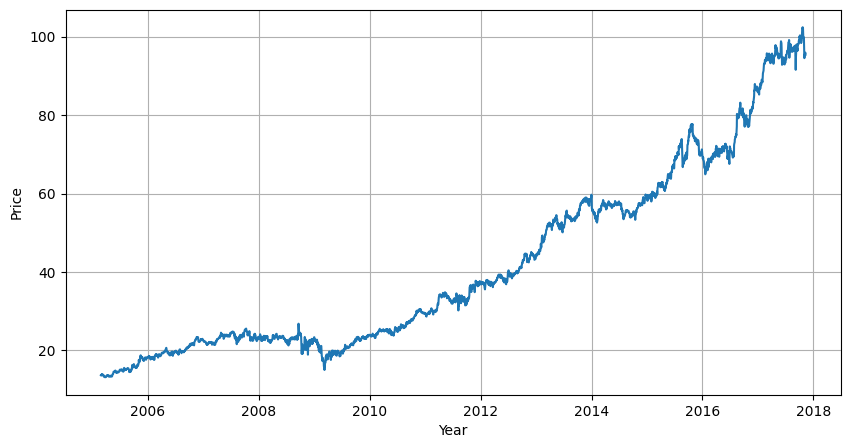

In [8]:
plt.figure(figsize=(10,5))
plt.plot(new_df)
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()
plt.show()

# Visualizing and Analyzing

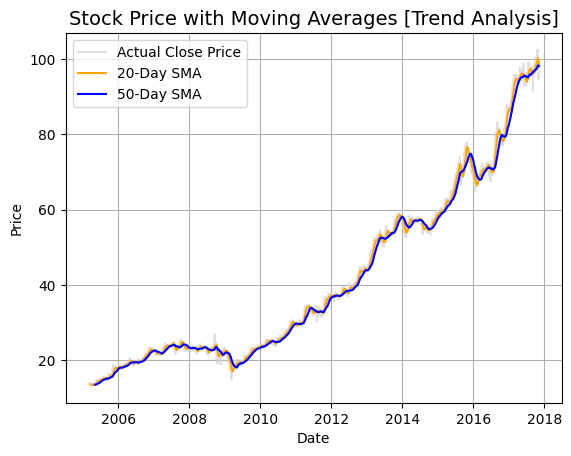

In [30]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

plt.plot(df.index, df['Close'], label='Actual Close Price', color='lightgray', alpha=0.7)
plt.plot(df.index, df['SMA_20'], label='20-Day SMA', color='orange', linewidth=1.5)
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', color='blue', linewidth=1.5)

plt.title('Stock Price with Moving Averages [Trend Analysis]', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()

plt.show()

# Model Training

In [32]:
series = df['Close']

In [12]:
# if ADF test val < 0.05 then data is stationary
result = adfuller(series)
print('Augmented Dickey-Fuller Results:', 'stationary-data' if result[1]<0.05 else 'non-stationary data')

Augmented Dickey-Fuller Results: non-stationary data


In [13]:
result[1]  

0.9969970726897868

In [14]:
series_diff = series.diff().dropna() # the number of times difference done to make data stationary. d = 1

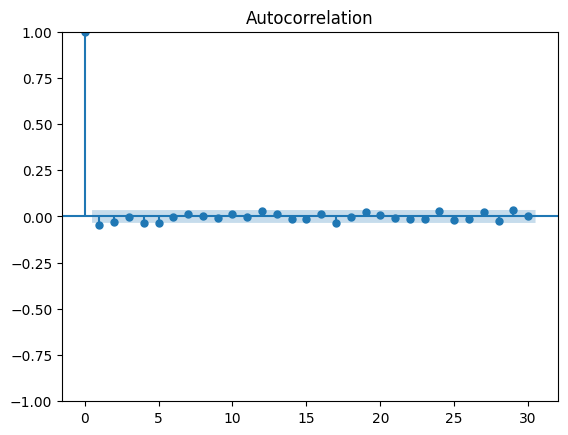

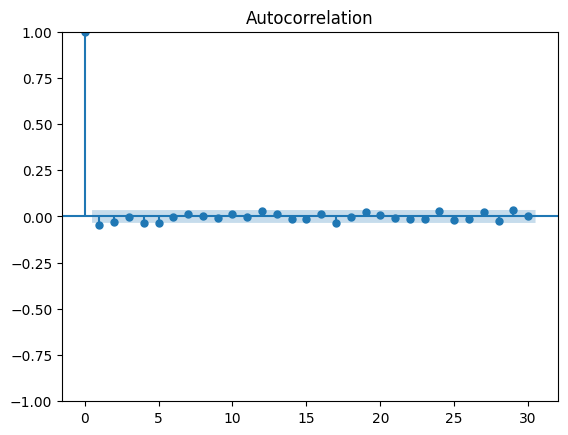

In [34]:
plot_acf(series_diff, lags=30) # q = 1 

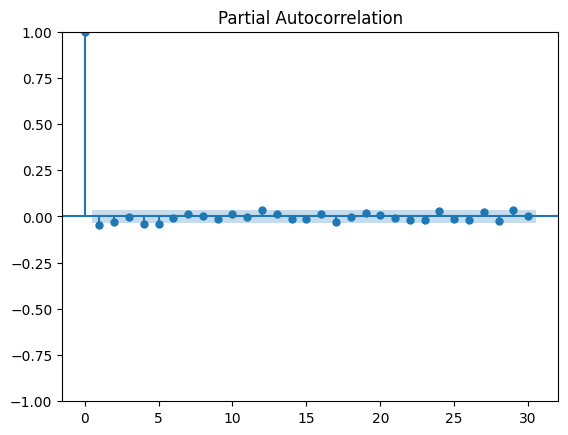

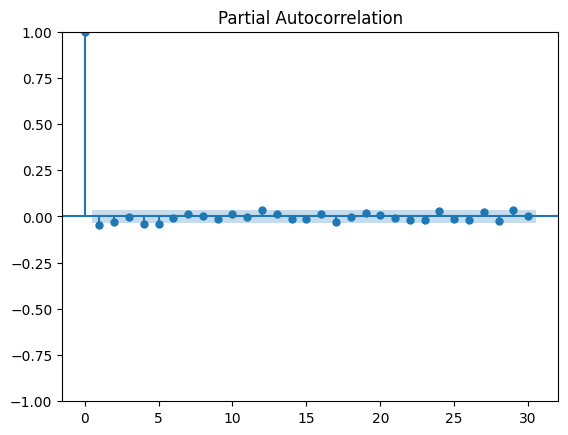

In [35]:
plot_pacf(series_diff, lags=30) # p = 1

In [16]:
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_squared_error

In [17]:
series = series.asfreq('B').ffill()

In [18]:
series.isna().sum()

0

In [19]:
int(len(series)*0.8)

2652

In [20]:
split_point  = int(len(series)*0.8)
train = series.iloc[:split_point]
test = series.iloc[split_point:]

In [21]:
model = ARIMA(train, order=(2,1,1)) # p=2, d=1, q=1
model_fit = model.fit()

# Forecasting

In [22]:
forecast_result = model_fit.get_forecast(steps=30)

In [54]:
forecast_values = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

In [ ]:
print(forecast_values)

In [ ]:
# Comparing forecasted price with actual test price
historic_stocks = test

plt.plot(historic_stocks.index, historic_stocks, color='blue', label='Actual Test Price')
plt.plot(forecast_values.index, forecast, color='red', label='Forecasted Price')
plt.fill_between(forecast_values.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='red', alpha=0.1, label='Confidence Int.')

plt.xticks(rotation=45)
plt.legend()
plt.show()

# Evaluation of Model

In [64]:
from sklearn.metrics import mean_squared_error

In [65]:
print('MSE:',mean_squared_error(test.iloc[0:30],forecast_values))

MSE: 7.886217582411366


(array([16556., 16563., 16570., 16577., 16587., 16594.]),
 [Text(16556.0, 0, '2015-05-01'),
  Text(16563.0, 0, '2015-05-08'),
  Text(16570.0, 0, '2015-05-15'),
  Text(16577.0, 0, '2015-05-22'),
  Text(16587.0, 0, '2015-06-01'),
  Text(16594.0, 0, '2015-06-08')])

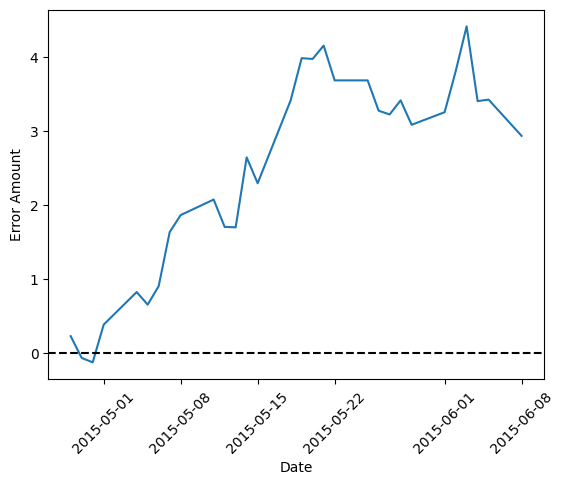

In [67]:
residual = test.iloc[:30] - forecast_values

sns.lineplot(x=test.iloc[:30].index, y=residual)
plt.axhline(0, color='black', linestyle='--')

plt.ylabel('Error Amount')
plt.xticks(rotation=45)